<a href="https://colab.research.google.com/github/siddhisalkar2005/CSL701-CE40_Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Siddhi Salkar        
Roll_No:CE40

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [4]:

# ============================================================
# TASK 1: ENVIRONMENT SETUP AND DATASET ACQUISITION
# ============================================================

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from sklearn.impute import SimpleImputer
from sklearn.ensemble import BaggingClassifier

print("All libraries imported successfully!")


# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Column names
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# Read dataset
df = pd.read_csv(
    url,
    header=None,
    names=columns
)


# ------------------------------------------------------------
# 1. First Five Records
# ------------------------------------------------------------

print("\nFirst Five Records:")
display(df.head())


# ------------------------------------------------------------
# 2. Dataset Shape
# ------------------------------------------------------------

print("\nDataset Shape:")
print(df.shape)


# ------------------------------------------------------------
# 3. Data Types
# ------------------------------------------------------------

print("\nData Types:")
print(df.dtypes)


# ------------------------------------------------------------
# 4. Descriptive Statistics
# ------------------------------------------------------------

print("\nDescriptive Statistics:")
display(df.describe())


All libraries imported successfully!

First Five Records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Absolute Count:
Non-Diabetic (0): 500
Diabetic (1): 268

Percentage:
Non-Diabetic (0): 65.1 %
Diabetic (1): 34.9 %

Class Balance:


,Class,Count,Percentage
0,Non-Diabetic,500,65.104167
1,Diabetic,268,34.895833


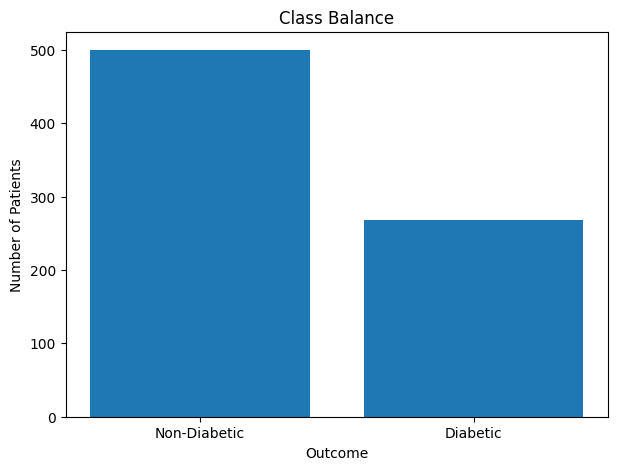

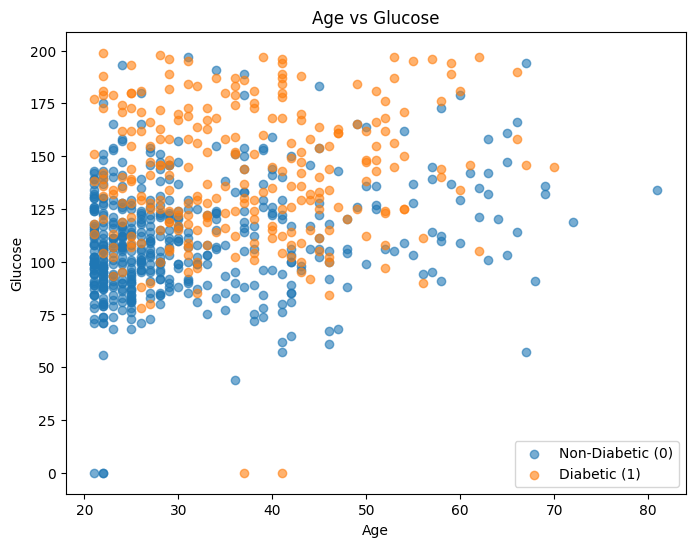

In [5]:
# ============================================================
# TASK 2: EXPLORATORY DATA ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. Calculate Absolute Count
# ------------------------------------------------------------

class_counts = df["Outcome"].value_counts().sort_index()

print("Absolute Count:")
print("Non-Diabetic (0):", class_counts[0])
print("Diabetic (1):", class_counts[1])


# ------------------------------------------------------------
# 2. Calculate Percentage
# ------------------------------------------------------------

class_percentages = (
    df["Outcome"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\nPercentage:")
print("Non-Diabetic (0):", round(class_percentages[0], 2), "%")
print("Diabetic (1):", round(class_percentages[1], 2), "%")


# ------------------------------------------------------------
# Create Summary Table
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Class": ["Non-Diabetic", "Diabetic"],
    "Count": [
        class_counts[0],
        class_counts[1]
    ],
    "Percentage": [
        class_percentages[0],
        class_percentages[1]
    ]
})

print("\nClass Balance:")
display(summary)


# ------------------------------------------------------------
# 3. Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Diabetic", "Diabetic"],
    [class_counts[0], class_counts[1]]
)

plt.title("Class Balance")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()


# ------------------------------------------------------------
# 4. Scatter Plot: Age vs Glucose
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

# Outcome 0
data_0 = df[df["Outcome"] == 0]

plt.scatter(
    data_0["Age"],
    data_0["Glucose"],
    label="Non-Diabetic (0)",
    alpha=0.6
)

# Outcome 1
data_1 = df[df["Outcome"] == 1]

plt.scatter(
    data_1["Age"],
    data_1["Glucose"],
    label="Diabetic (1)",
    alpha=0.6
)

plt.title("Age vs Glucose")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.legend()

plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [6]:
# ============================================================
# TASK 3: PREPROCESSING AND HANDLING MISSING VALUES
# ============================================================

# Create a copy of original dataset
df_clean = df.copy()


# ------------------------------------------------------------
# Features where 0 is invalid
# ------------------------------------------------------------

invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]


# ------------------------------------------------------------
# 1. Identify Zero Values
# ------------------------------------------------------------

print("Zero values before replacement:\n")

for column in invalid_zero_columns:
    zero_count = (df_clean[column] == 0).sum()
    print(column, ":", zero_count)


# ------------------------------------------------------------
# 2. Replace 0 with NaN
# ------------------------------------------------------------

df_clean[invalid_zero_columns] = (
    df_clean[invalid_zero_columns]
    .replace(0, np.nan)
)


print("\nMissing values after replacing 0 with NaN:")
print(df_clean.isnull().sum())


# ------------------------------------------------------------
# 3. Median Imputation
# ------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

df_clean[invalid_zero_columns] = (
    imputer.fit_transform(
        df_clean[invalid_zero_columns]
    )
)


# ------------------------------------------------------------
# Check Missing Values
# ------------------------------------------------------------

print("\nMissing values after median imputation:")
print(df_clean.isnull().sum())


# ------------------------------------------------------------
# Display Cleaned Dataset
# ------------------------------------------------------------

print("\nCleaned Dataset:")
display(df_clean.head())

Zero values before replacement:

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11

Missing values after replacing 0 with NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Cleaned Dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [7]:
# ============================================================
# TASK 4: STRATIFIED TRAIN-TEST SPLITTING
# ============================================================


# ------------------------------------------------------------
# 1. Separate X and y
# ------------------------------------------------------------

# First 8 columns = Features
X = df_clean.iloc[:, :8].values

# 9th column = Target
y = df_clean.iloc[:, 8].values


print("Feature Matrix X Shape:")
print(X.shape)

print("\nTarget Vector y Shape:")
print(y.shape)


# ------------------------------------------------------------
# 2. 80% Training and 20% Testing
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# Display Shapes
# ------------------------------------------------------------

print("\nTraining Data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# ------------------------------------------------------------
# Check Class Distribution
# ------------------------------------------------------------

print("\nTraining Class Distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting Class Distribution:")
print(pd.Series(y_test).value_counts())

Feature Matrix X Shape:
(768, 8)

Target Vector y Shape:
(768,)

Training Data:
X_train: (614, 8)
y_train: (614,)

Testing Data:
X_test: (154, 8)
y_test: (154,)

Training Class Distribution:
0    400
1    214
Name: count, dtype: int64

Testing Class Distribution:
0    100
1     54
Name: count, dtype: int64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [8]:
# ============================================================
# TASK 5: CUSTOM BOOTSTRAP SAMPLING FUNCTION
# ============================================================


def get_bootstrap_sample(X, y):

    # Number of samples
    n_samples = len(X)

    # Generate random indices WITH REPLACEMENT
    indices = np.random.randint(
        0,
        n_samples,
        size=n_samples
    )

    # Create bootstrap dataset
    X_bootstrap = X[indices]
    y_bootstrap = y[indices]

    return X_bootstrap, y_bootstrap, indices


# ------------------------------------------------------------
# Test the Bootstrap Function
# ------------------------------------------------------------

X_bootstrap, y_bootstrap, bootstrap_indices = (
    get_bootstrap_sample(X_train, y_train)
)


# ------------------------------------------------------------
# Check Size
# ------------------------------------------------------------

print("Original Training Size:",
      len(X_train))

print("Bootstrap Sample Size:",
      len(X_bootstrap))


# ------------------------------------------------------------
# Find Duplicate Indices
# ------------------------------------------------------------

unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

duplicate_indices = unique_indices[counts > 1]


# ------------------------------------------------------------
# Find OOB Indices
# ------------------------------------------------------------

all_indices = set(range(len(X_train)))

selected_indices = set(
    bootstrap_indices
)

oob_indices = sorted(
    list(all_indices - selected_indices)
)


# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

print("\nNumber of Unique Samples:",
      len(unique_indices))

print("Number of Duplicated Samples:",
      len(duplicate_indices))

print("Number of OOB Samples:",
      len(oob_indices))

print("\nSome Duplicate Indices:")
print(duplicate_indices[:10])

print("\nSome OOB Indices:")
print(oob_indices[:10])

Original Training Size: 614
Bootstrap Sample Size: 614

Number of Unique Samples: 376
Number of Duplicated Samples: 164
Number of OOB Samples: 238

Some Duplicate Indices:
[ 0  1  3  4  6 22 24 28 30 32]

Some OOB Indices:
[2, 7, 11, 13, 15, 17, 19, 20, 23, 34]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [9]:
# ============================================================
# TASK 6: GROWING THE ENSEMBLE OF BASE CLASSIFIERS
# ============================================================


# Number of Decision Trees
B = 50


# Empty list to store trees
ensemble = []


# ------------------------------------------------------------
# Train 50 Decision Trees
# ------------------------------------------------------------

for b in range(B):

    # Step 1: Bootstrap sample
    X_bootstrap, y_bootstrap, indices = (
        get_bootstrap_sample(
            X_train,
            y_train
        )
    )

    # Step 2: Create Decision Tree
    tree = DecisionTreeClassifier(
        max_depth=None,
        random_state=100 + b
    )

    # Step 3: Train Decision Tree
    tree.fit(
        X_bootstrap,
        y_bootstrap
    )

    # Step 4: Store tree
    ensemble.append(tree)


# ------------------------------------------------------------
# Check Ensemble
# ------------------------------------------------------------

print("Ensemble Training Completed!")

print("Number of Decision Trees:",
      len(ensemble))


Ensemble Training Completed!
Number of Decision Trees: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [10]:
# ============================================================
# TASK 7: MAJORITY VOTING FROM SCRATCH
# ============================================================


def custom_bagging_predict(ensemble, X_test):

    # Store predictions from every tree
    all_predictions = []


    # --------------------------------------------------------
    # Get predictions from each tree
    # --------------------------------------------------------

    for tree in ensemble:

        predictions = tree.predict(X_test)

        all_predictions.append(predictions)


    # Convert list to NumPy array
    all_predictions = np.array(
        all_predictions
    )


    # --------------------------------------------------------
    # Majority Voting
    # --------------------------------------------------------

    final_predictions = []


    for i in range(X_test.shape[0]):

        # Get predictions of all 50 trees
        votes = all_predictions[:, i]

        # Count class 0 votes
        votes_0 = np.sum(votes == 0)

        # Count class 1 votes
        votes_1 = np.sum(votes == 1)


        # Majority decision
        if votes_1 > votes_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)


    return np.array(final_predictions)


# ------------------------------------------------------------
# Make Bagging Predictions
# ------------------------------------------------------------

y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


print("Bagging Predictions:")
print(y_pred_bagging)

print("\nNumber of Predictions:",
      len(y_pred_bagging))

Bagging Predictions:
[1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 1 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0
 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 1 0]

Number of Predictions: 154


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [11]:
# ============================================================
# TASK 8: SINGLE DECISION TREE VS CUSTOM BAGGING
# ============================================================


# ------------------------------------------------------------
# 1. Train Single Decision Tree
# ------------------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 2. Predict Using Single Tree
# ------------------------------------------------------------

y_pred_single = single_tree.predict(
    X_test
)


# ------------------------------------------------------------
# 3. Bagging Predictions
# ------------------------------------------------------------

y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# ------------------------------------------------------------
# 4. Calculate Single Tree Metrics
# ------------------------------------------------------------

single_accuracy = accuracy_score(
    y_test,
    y_pred_single
)

single_precision = precision_score(
    y_test,
    y_pred_single,
    zero_division=0
)

single_recall = recall_score(
    y_test,
    y_pred_single,
    zero_division=0
)

single_f1 = f1_score(
    y_test,
    y_pred_single,
    zero_division=0
)


# ------------------------------------------------------------
# 5. Calculate Bagging Metrics
# ------------------------------------------------------------

bagging_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)

bagging_precision = precision_score(
    y_test,
    y_pred_bagging,
    zero_division=0
)

bagging_recall = recall_score(
    y_test,
    y_pred_bagging,
    zero_division=0
)

bagging_f1 = f1_score(
    y_test,
    y_pred_bagging,
    zero_division=0
)


# ------------------------------------------------------------
# 6. Display Results
# ------------------------------------------------------------

results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Single Decision Tree": [
        single_accuracy,
        single_precision,
        single_recall,
        single_f1
    ],

    "Custom Bagging": [
        bagging_accuracy,
        bagging_precision,
        bagging_recall,
        bagging_f1
    ]
})


print("Performance Comparison:")

display(
    results.round(4)
)

Performance Comparison:


,Metric,Single Decision Tree,Custom Bagging
0,Accuracy,0.6818,0.7338
1,Precision,0.5532,0.6383
2,Recall,0.4815,0.5556
3,F1-Score,0.5149,0.5941


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Single Decision Tree AUC: 0.6357
Custom Bagging AUC: 0.8039


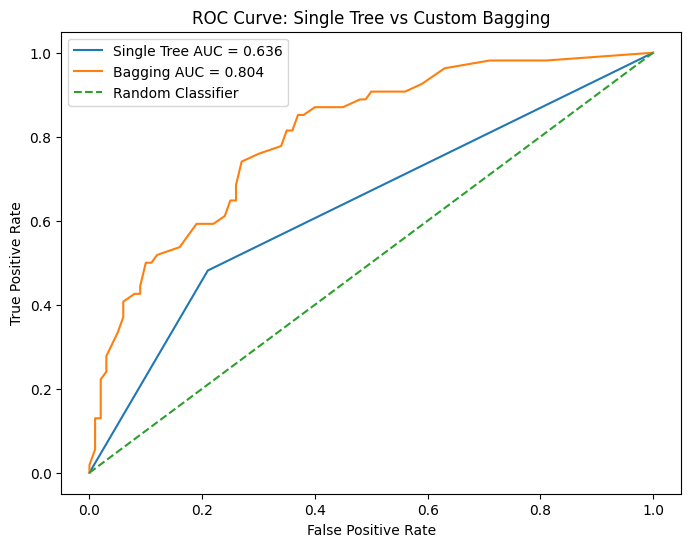

In [12]:
# ============================================================
# TASK 9: ROC-AUC ANALYSIS
# ============================================================


# ------------------------------------------------------------
# 1. Single Decision Tree Probability
# ------------------------------------------------------------

single_probabilities = (
    single_tree
    .predict_proba(X_test)[:, 1]
)


# ------------------------------------------------------------
# 2. Get Probability from Every Bagging Tree
# ------------------------------------------------------------

all_probabilities = []


for tree in ensemble:

    probability = (
        tree
        .predict_proba(X_test)[:, 1]
    )

    all_probabilities.append(
        probability
    )


# Convert to NumPy array
all_probabilities = np.array(
    all_probabilities
)


# ------------------------------------------------------------
# 3. Average Probabilities
# ------------------------------------------------------------

bagging_probabilities = np.mean(
    all_probabilities,
    axis=0
)


# ------------------------------------------------------------
# 4. Calculate ROC
# ------------------------------------------------------------

fpr_single, tpr_single, _ = roc_curve(
    y_test,
    single_probabilities
)

fpr_bagging, tpr_bagging, _ = roc_curve(
    y_test,
    bagging_probabilities
)


# ------------------------------------------------------------
# 5. Calculate AUC
# ------------------------------------------------------------

auc_single = roc_auc_score(
    y_test,
    single_probabilities
)

auc_bagging = roc_auc_score(
    y_test,
    bagging_probabilities
)


print("Single Decision Tree AUC:",
      round(auc_single, 4))

print("Custom Bagging AUC:",
      round(auc_bagging, 4))


# ------------------------------------------------------------
# 6. Plot ROC Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Tree AUC = {auc_single:.3f}"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Bagging AUC = {auc_bagging:.3f}"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve: Single Tree vs Custom Bagging"
)

plt.legend()

plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [13]:
# ============================================================
# TASK 10: SCIKIT-LEARN BAGGING CLASSIFIER
# ============================================================


# ------------------------------------------------------------
# 1. Create Base Decision Tree
# ------------------------------------------------------------

base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)


# ------------------------------------------------------------
# 2. Create BaggingClassifier
# ------------------------------------------------------------

# New versions of Scikit-Learn use estimator=
# Older versions use base_estimator=

try:

    sklearn_bagging = BaggingClassifier(
        estimator=base_tree,
        n_estimators=50,
        random_state=42
    )

except TypeError:

    sklearn_bagging = BaggingClassifier(
        base_estimator=base_tree,
        n_estimators=50,
        random_state=42
    )


# ------------------------------------------------------------
# 3. Train Model
# ------------------------------------------------------------

sklearn_bagging.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 4. Predict
# ------------------------------------------------------------

y_pred_sklearn = sklearn_bagging.predict(
    X_test
)


# ------------------------------------------------------------
# 5. Accuracy
# ------------------------------------------------------------

sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)


print(
    "Scikit-Learn Bagging Accuracy:",
    round(sklearn_accuracy, 4)
)


# ------------------------------------------------------------
# 6. Confusion Matrix
# ------------------------------------------------------------

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)


print("\nScikit-Learn Bagging Confusion Matrix:")

print(cm_sklearn)

Scikit-Learn Bagging Accuracy: 0.7338

Scikit-Learn Bagging Confusion Matrix:
[[85 15]
 [26 28]]


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?